# Figures

Every figure in the report is generated here, so none of them is drawn by hand.

# Setup and the house style

Colours and sizes come from settings.yaml, the same file the site reads.

In [1]:
%matplotlib inline
# the magic above is the actual fix and it has to be a magic, not an import setting.
# this notebook used to call matplotlib.use('Agg'). Agg draws to a file and never to a
# screen, so every chart landed in figures/ and none appeared under the cell that drew
# it. deleting that call is not enough on its own: a backend, once set, lasts as long
# as the python process, so a kernel that had already run the old code stayed on Agg
# whatever the file said afterwards. the magic switches the running kernel over

import json
import numpy as np
import pandas as pd
import yaml
import matplotlib
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')
from IPython.display import display

project_root=Path.cwd().parent if Path.cwd().name=='notebooks' else Path.cwd()
settings=yaml.safe_load((project_root/'notebooks'/'config.yaml').read_text())
palette=settings['palette']
figures_dir=project_root/settings['paths']['figures']
tables_dir=project_root/settings['paths']['tables']
figures_dir.mkdir(parents=True,exist_ok=True)

# i pull every colour by name so no hex is typed here. the report is light mode
INK=palette['ink']
COLOUR={'health':palette['series']['health_score']['light'],
        'baseline':palette['series']['review_baseline']['light'],
        'dummy':palette['series']['dummy']['light'],
        'boost':palette['series']['boosting']['light'],
        'at_risk':palette['status']['at_risk'],
        'needs':palette['status']['needs_attention'],
        'healthy':palette['status']['healthy']}
PRIMARY,SECONDARY,MUTED=INK['primary']['light'],INK['secondary']['light'],INK['muted']['light']
GRID,AXIS,SURFACE=INK['gridline']['light'],INK['axis']['light'],INK['chart_surface']['light']

text_width=settings['figures']['latex_text_width_inches']

plt.rcParams.update({
    'figure.facecolor':SURFACE,'axes.facecolor':SURFACE,
    'savefig.facecolor':SURFACE,'savefig.bbox':'tight','savefig.pad_inches':0.02,
    'font.size':8,'axes.titlesize':9,'axes.labelsize':8,
    'axes.edgecolor':AXIS,'axes.linewidth':0.8,
    'axes.spines.top':False,'axes.spines.right':False,
    'axes.labelcolor':SECONDARY,'text.color':PRIMARY,
    'xtick.color':MUTED,'ytick.color':MUTED,'xtick.labelsize':7,'ytick.labelsize':7,
    'grid.color':GRID,'grid.linewidth':0.6,'legend.frameon':False,'legend.fontsize':7,
    'lines.linewidth':2.0,'lines.markersize':5})


def save(fig,name):
    """png only. the report, the slides and both dashboards all take raster.
    saves, then shows the chart under the cell that drew it, then closes it so
    eleven figures are never open at once"""
    fig.savefig(figures_dir/f'{name}.png',dpi=settings['figures']['dpi'])
    # display before close. closing first is what used to leave plt.show() with
    # nothing left to draw
    display(fig)
    plt.close(fig)
    print(f'  saved {name}.png')


# now i load every table this notebook draws from, once
tables={p.stem:pd.read_csv(p) for p in tables_dir.glob('*.csv')}
scores=pd.read_parquet(project_root/settings['paths']['game_scores'])
features=pd.read_parquet(project_root/settings['paths']['game_features'])

print('figures ->',figures_dir)
# if this ever prints Agg again the charts will save but not show, so check it first
print('backend :',matplotlib.get_backend())
print('tables available:',len(tables))
print('text width:',text_width,'inches')

figures -> D:\Msc_Data_Analytics\Research_Practicum_final\final_thesis\figures
backend : inline
tables available: 19
text width: 5.5 inches


# The results figures

In the order the results section argues them: the headline first, then the figures that support it or name its limits.

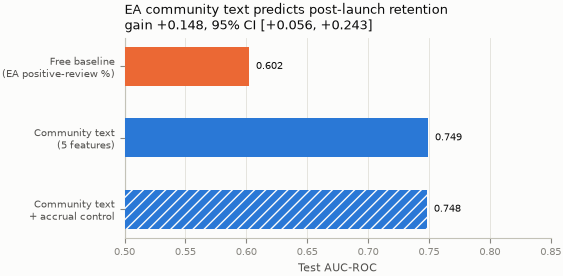

  saved fig01_cross_instrument_gain.png


In [2]:
# F1 : the cross-instrument gain, my headline figure
cross=tables['cross_instrument_model'].set_index('model')['test_auc_roc']
fig,ax=plt.subplots(figsize=(text_width,2.6))

labels=['Free baseline\n(EA positive-review %)','Community text\n(5 features)','Community text\n+ accrual control']
values=[cross['free baseline'],cross['cross-instrument (community text)'],
        cross['cross-instrument + accrual control']]
colours=[COLOUR['baseline'],COLOUR['health'],COLOUR['health']]

bars=ax.barh(range(len(values)),values,height=0.55,color=colours,zorder=3)
# the third bar is the same model as the second so i hatch it, a new colour would
# make it look like a different model
bars[2].set_hatch('///'); bars[2].set_edgecolor(SURFACE); bars[2].set_linewidth(0)

ax.set_yticks(range(len(values))); ax.set_yticklabels(labels,fontsize=7,color=SECONDARY)
ax.invert_yaxis()
ax.set_xlim(0.5,0.85); ax.set_xlabel('Test AUC-ROC')
ax.axvline(0.5,color=AXIS,lw=0.8,zorder=1)
ax.xaxis.grid(True,zorder=0); ax.set_axisbelow(True)

# only three bars here so i label each one
for bar,value in zip(bars,values):
    ax.text(value+0.006,bar.get_y()+bar.get_height()/2,f'{value:.3f}',
            va='center',fontsize=7,color=PRIMARY)

gain=cross['GAIN over baseline (bootstrap mean)']
ax.set_title(f'EA community text predicts post-launch retention\n'
             f'gain +{gain:.3f}, 95% CI [{cross["gain 95% CI low"]:+.3f}, {cross["gain 95% CI high"]:+.3f}]',
             color=PRIMARY,loc='left')

save(fig,'fig01_cross_instrument_gain')

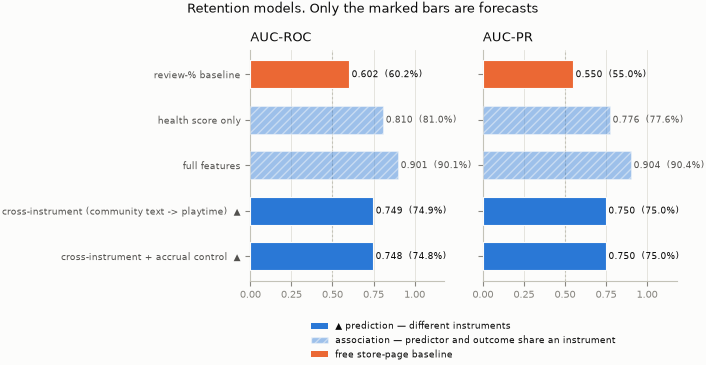

  saved fig02_model_comparison.png


In [3]:
# F2 : model comparison, with the associations kept apart from the predictions
# when i drew this with one colour the 0.902 association sat above the 0.752
# prediction and looked like the better result, which is the opposite of what i claim.
# so now i hatch and fade the associations and mark the predictions
comparison=tables['model_comparison']
retention=comparison[comparison['run'].str.startswith('retention')].copy()
retention['short']=(retention['run'].str.split('·').str[-1].str.strip()
                    .str.replace('^[0-9]b? ','',regex=True))
retention=retention.drop_duplicates('short').head(5)

# a model is only a prediction when the predictor and the outcome use different instruments
is_prediction=retention['short'].str.contains('cross-instrument')
is_baseline=retention['short'].str.contains('review-%')

fig,axes=plt.subplots(1,2,figsize=(text_width,3.0),sharey=True)
for ax,metric,title in zip(axes,['test_auc_roc','test_auc_pr'],['AUC-ROC','AUC-PR']):
    for i,(value,pred,base) in enumerate(zip(retention[metric],is_prediction,is_baseline)):
        colour=COLOUR['baseline'] if base else COLOUR['health']
        ax.barh(i,value,height=0.62,color=colour,zorder=3,
                alpha=1.0 if (pred or base) else 0.45,
                hatch=None if (pred or base) else '////',
                edgecolor=SURFACE,linewidth=0.8)
        ax.text(value+0.015,i,f'{value:.3f}  ({value*100:.1f}%)',va='center',
                fontsize=6.2,color=PRIMARY if (pred or base) else SECONDARY)
    ax.axvline(0.5,color=AXIS,lw=0.8,ls=(0,(2,2)),zorder=1)
    ax.set_xlim(0,1.18); ax.set_title(title,color=PRIMARY,loc='left',pad=6)
    ax.xaxis.grid(True,zorder=0); ax.set_axisbelow(True)
    ax.set_xticks([0,0.25,0.5,0.75,1.0])

labels=[s+('  ▲' if p else '') for s,p in zip(retention['short'],is_prediction)]
axes[0].set_yticks(range(len(retention)))
axes[0].set_yticklabels(labels,fontsize=6.5,color=SECONDARY)
axes[0].invert_yaxis()

from matplotlib.patches import Patch
axes[1].legend(handles=[
    Patch(facecolor=COLOUR['health'],label='▲ prediction — different instruments'),
    Patch(facecolor=COLOUR['health'],alpha=0.45,hatch='////',edgecolor=SURFACE,
          label='association — predictor and outcome share an instrument'),
    Patch(facecolor=COLOUR['baseline'],label='free store-page baseline')],
    loc='upper center',bbox_to_anchor=(-0.1,-0.14),ncol=1,fontsize=6.2)
fig.suptitle('Retention models. Only the marked bars are forecasts',
             color=PRIMARY,x=0.01,ha='left',fontsize=9,y=1.04)
save(fig,'fig02_model_comparison')
plt.show()

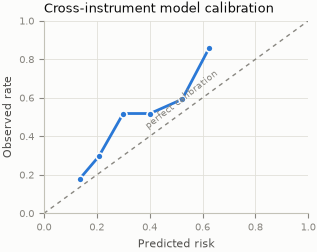

  saved fig03_calibration.png


In [4]:
# F3 : calibration
calibration=tables['calibration_cross_instrument']
fig,ax=plt.subplots(figsize=(text_width*0.62,2.5))
ax.plot([0,1],[0,1],color=MUTED,lw=1,ls=(0,(3,3)),zorder=1)
ax.plot(calibration['predicted_risk'],calibration['observed_rate'],
        marker='o',color=COLOUR['health'],zorder=3,
        markerfacecolor=COLOUR['health'],markeredgecolor=SURFACE,markeredgewidth=1.2)
ax.text(0.52,0.44,'perfect calibration',fontsize=6.5,color=MUTED,rotation=38,ha='center')
ax.set_xlabel('Predicted risk'); ax.set_ylabel('Observed rate')
ax.set_xlim(0,1); ax.set_ylim(0,1); ax.grid(True,zorder=0); ax.set_axisbelow(True)
ax.set_title('Cross-instrument model calibration',color=PRIMARY,loc='left')
save(fig,'fig03_calibration')
plt.show()

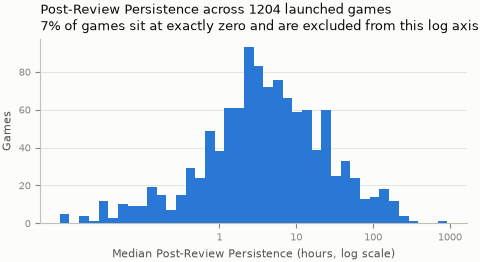

  saved fig04_persistence_distribution.png


In [5]:
# F4 : the Post-Review Persistence distribution
# i use a log x axis here because playtime is heavily right skewed and a linear one
# would show one bar at zero and nothing else
persistence=features.loc[features['prp_median_hours'].notna() &
                         (features['cohort']=='launched'),'prp_median_hours']
fig,ax=plt.subplots(figsize=(text_width,2.4))
positive=persistence[persistence>0]
ax.hist(np.log10(positive),bins=40,color=COLOUR['health'],zorder=3)
ax.set_xlabel('Median Post-Review Persistence (hours, log scale)')
ax.set_ylabel('Games')
ticks=[0,1,2,3]
ax.set_xticks(ticks); ax.set_xticklabels([f'{10**t:g}' for t in ticks])
ax.yaxis.grid(True,zorder=0); ax.set_axisbelow(True)

zero_share=(persistence==0).mean()
ax.set_title(f'Post-Review Persistence across {len(persistence)} launched games\n'
             f'{zero_share:.0%} of games sit at exactly zero and are excluded from this log axis',
             color=PRIMARY,loc='left')
save(fig,'fig04_persistence_distribution')
plt.show()

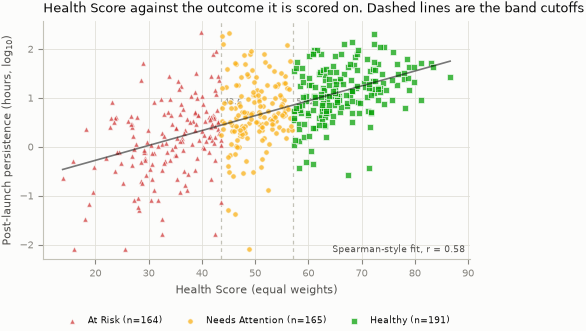

  saved fig05_score_vs_outcome.png


In [6]:
# F5 : the health score against the outcome, coloured by band
# the legend used to sit on top of the points so i move it out, and i draw the two
# band cutoffs so the colour changes have a visible cause
modelled=scores[scores['cohort']=='launched'].copy()
fig,ax=plt.subplots(figsize=(text_width,3.1))

for cut in (settings['bands']['at_risk_below'],settings['bands']['healthy_at_or_above']):
    ax.axvline(cut,color=AXIS,lw=0.9,ls=(0,(3,3)),zorder=1)
    ax.text(cut,ax.get_ylim()[1],f' {cut}',fontsize=6,color=MUTED,va='top')

band_style={'At Risk':(COLOUR['at_risk'],'^'),'Needs Attention':(COLOUR['needs'],'o'),
            'Healthy':(COLOUR['healthy'],'s')}
for band,(colour,marker) in band_style.items():
    subset=modelled[(modelled['health_band']==band)&modelled['post_prp_median_hours'].notna()]
    subset=subset[subset['post_prp_median_hours']>0]
    ax.scatter(subset['health_score_equal'],np.log10(subset['post_prp_median_hours']),
               s=15,c=colour,marker=marker,label=f'{band} (n={len(subset)})',alpha=0.75,
               linewidths=0.6,edgecolors=SURFACE,zorder=3)

# now i fit a line to state the direction the eye is already looking for
ok=modelled[modelled['post_prp_median_hours']>0]
xs=ok['health_score_equal'].values; ys=np.log10(ok['post_prp_median_hours'].values)
slope,intercept=np.polyfit(xs,ys,1)
grid=np.linspace(xs.min(),xs.max(),50)
ax.plot(grid,slope*grid+intercept,color=PRIMARY,lw=1.2,ls='-',zorder=4,alpha=0.55)
r=np.corrcoef(xs,ys)[0,1]
ax.text(0.99,0.03,f'Spearman-style fit, r = {r:.2f}',transform=ax.transAxes,
        ha='right',fontsize=6.5,color=SECONDARY)

ax.set_xlabel('Health Score (equal weights)')
ax.set_ylabel('Post-launch persistence (hours, log$_{10}$)')
ax.grid(True,zorder=0); ax.set_axisbelow(True)
ax.legend(loc='upper center',bbox_to_anchor=(0.5,-0.20),ncol=3,fontsize=6.5)
ax.set_title('Health Score against the outcome it is scored on. Dashed lines are the band cutoffs',
             color=PRIMARY,loc='left')
save(fig,'fig05_score_vs_outcome')
plt.show()

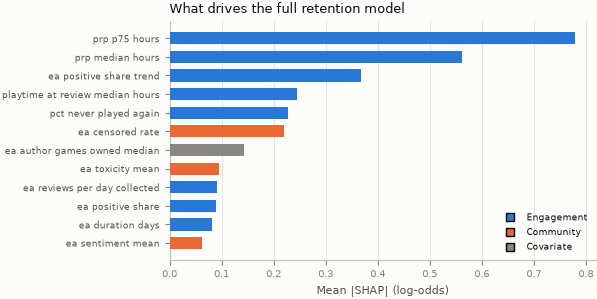

  saved fig06_shap_importance.png


In [7]:
# F6 : the SHAP summary
shap_importance=tables['shap_importance'].set_index(tables['shap_importance'].columns[0])
shap_importance=shap_importance.iloc[:,0].sort_values(ascending=True).tail(12)

engagement=set(settings['predictors']['engagement'])
community=set(settings['predictors']['community'])
colours=[COLOUR['health'] if f in engagement else
         COLOUR['baseline'] if f in community else MUTED for f in shap_importance.index]

fig,ax=plt.subplots(figsize=(text_width,3.1))
ax.barh(range(len(shap_importance)),shap_importance.values,height=0.65,color=colours,zorder=3)
ax.set_yticks(range(len(shap_importance)))
ax.set_yticklabels([f.replace('_',' ') for f in shap_importance.index],fontsize=6.5,color=SECONDARY)
ax.set_xlabel('Mean |SHAP| (log-odds)')
ax.xaxis.grid(True,zorder=0); ax.set_axisbelow(True)

handles=[plt.Line2D([0],[0],marker='s',color='none',markerfacecolor=c,markersize=6,label=l)
         for c,l in [(COLOUR['health'],'Engagement'),(COLOUR['baseline'],'Community'),(MUTED,'Covariate')]]
ax.legend(handles=handles,loc='lower right',fontsize=6.5)
ax.set_title('What drives the full retention model',color=PRIMARY,loc='left')
save(fig,'fig06_shap_importance')
plt.show()

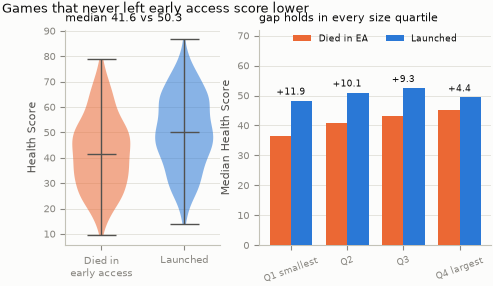

  saved fig07_survivorship.png


In [8]:
# F7 : died-in-EA against launched, my survivorship check
by_size=tables['survivorship_by_size']
fig,axes=plt.subplots(1,2,figsize=(text_width,2.8),gridspec_kw={'width_ratios':[1,1.5]})

# on the left i show the overall distributions
launched=scores.loc[scores['cohort']=='launched','health_score_equal']
died=scores.loc[scores['cohort']=='died_in_early_access','health_score_equal']
parts=axes[0].violinplot([died.values,launched.values],showmedians=True,widths=0.7)
# i use series colours here, not the status ones. these are cohorts, and the status
# colours are reserved for the bands. reusing them would also put red next to green,
# which is the worst pair for a colourblind reader
for body,colour in zip(parts['bodies'],[COLOUR['baseline'],COLOUR['health']]):
    body.set_facecolor(colour); body.set_alpha(0.55); body.set_edgecolor('none')
for key in ('cmedians','cbars','cmins','cmaxes'):
    if key in parts: parts[key].set_color(SECONDARY); parts[key].set_linewidth(1)
axes[0].set_xticks([1,2]); axes[0].set_xticklabels(['Died in\nearly access','Launched'],fontsize=7)
axes[0].set_ylabel('Health Score'); axes[0].yaxis.grid(True,zorder=0); axes[0].set_axisbelow(True)
axes[0].set_title(f'median {died.median():.1f} vs {launched.median():.1f}',
                  color=PRIMARY,loc='left',fontsize=8)

# and it holds inside every size band, which is the objection worth answering
x=np.arange(len(by_size)); width=0.38
axes[1].bar(x-width/2,by_size['median_died'],width,color=COLOUR['baseline'],label='Died in EA',zorder=3)
axes[1].bar(x+width/2,by_size['median_launched'],width,color=COLOUR['health'],label='Launched',zorder=3)
axes[1].set_xticks(x); axes[1].set_xticklabels(by_size['size_band'],fontsize=6.5,rotation=20)
axes[1].set_ylabel('Median Health Score')
# i leave headroom so the legend does not land on the gap labels
axes[1].set_ylim(0,72)
axes[1].yaxis.grid(True,zorder=0); axes[1].set_axisbelow(True)
axes[1].legend(fontsize=6.5,ncol=2,loc='upper center',bbox_to_anchor=(0.5,1.02))
for i,gap in enumerate(by_size['gap']):
    axes[1].text(i,max(by_size['median_launched'].iloc[i],by_size['median_died'].iloc[i])+2,
                 f'+{gap}',ha='center',fontsize=6.5,color=PRIMARY)
axes[1].set_title('gap holds in every size quartile',color=PRIMARY,loc='left',fontsize=8)

fig.suptitle('Games that never left early access score lower',color=PRIMARY,x=0.01,ha='left',fontsize=9)
save(fig,'fig07_survivorship')
plt.show()

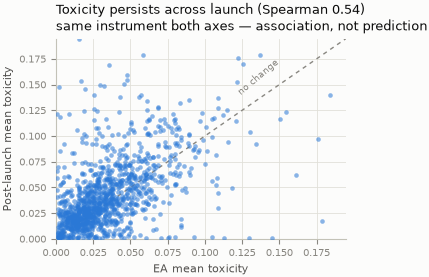

  saved fig08_toxicity_trajectory.png


In [9]:
# F8 : the toxicity trajectory, early access against post launch
launched_games=features[features['cohort']=='launched'].dropna(
    subset=['ea_toxicity_mean','post_toxicity_mean'])
fig,ax=plt.subplots(figsize=(text_width*0.68,2.6))
ax.scatter(launched_games['ea_toxicity_mean'],launched_games['post_toxicity_mean'],
           s=11,c=COLOUR['health'],alpha=0.55,linewidths=0,zorder=3)
limit=max(launched_games['ea_toxicity_mean'].quantile(0.99),
          launched_games['post_toxicity_mean'].quantile(0.99))
ax.plot([0,limit],[0,limit],color=MUTED,lw=1,ls=(0,(3,3)),zorder=2)
ax.text(limit*0.62,limit*0.72,'no change',fontsize=6.5,color=MUTED,rotation=40)
ax.set_xlim(0,limit); ax.set_ylim(0,limit)
ax.set_xlabel('EA mean toxicity'); ax.set_ylabel('Post-launch mean toxicity')
ax.grid(True,zorder=0); ax.set_axisbelow(True)
correlation=launched_games['ea_toxicity_mean'].corr(launched_games['post_toxicity_mean'],method='spearman')
ax.set_title(f'Toxicity persists across launch (Spearman {correlation:.2f})\n'
             'same instrument both axes — association, not prediction',color=PRIMARY,loc='left')
save(fig,'fig08_toxicity_trajectory')
plt.show()

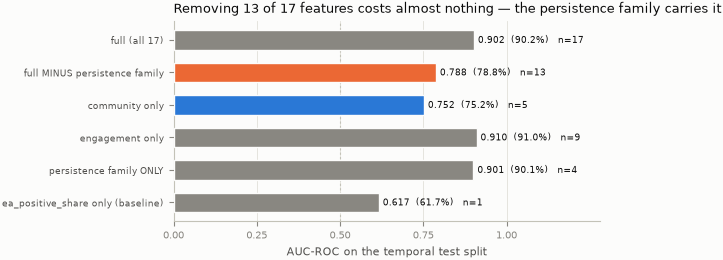

  saved fig09_leakage_ablation.png


In [10]:
# F9 : the leakage ablation, drawn rather than tabulated
# this is the figure i least want to leave out. the 17 features and the 4 persistence
# ones score the same, which is how i know the headline association is measurement
# rather than modelling
abl=tables['leakage_ablation']
abl=abl[abl['outcome']=='retention'].copy()
abl['label']=abl['features'].str.replace('^[A-Z]\. ','',regex=True)

fig,ax=plt.subplots(figsize=(text_width,2.6))
colours=[COLOUR['health'] if 'community' in s else
         (COLOUR['baseline'] if 'persistence only' in s or 'MINUS' in s else MUTED)
         for s in abl['label']]
ax.barh(range(len(abl)),abl['test_auc_roc'],height=0.6,color=colours,zorder=3,edgecolor=SURFACE)
for i,(v,n) in enumerate(zip(abl['test_auc_roc'],abl['n'])):
    ax.text(v+0.012,i,f'{v:.3f}  ({v*100:.1f}%)   n={n}',va='center',fontsize=6.3,color=PRIMARY)
ax.axvline(0.5,color=AXIS,lw=0.8,ls=(0,(2,2)),zorder=1)
ax.set_yticks(range(len(abl))); ax.set_yticklabels(abl['label'],fontsize=6.5,color=SECONDARY)
ax.invert_yaxis(); ax.set_xlim(0,1.28); ax.set_xticks([0,0.25,0.5,0.75,1.0])
ax.xaxis.grid(True,zorder=0); ax.set_axisbelow(True)
ax.set_xlabel('AUC-ROC on the temporal test split')
ax.set_title('Removing 13 of 17 features costs almost nothing — the persistence family carries it',
             color=PRIMARY,loc='left')
save(fig,'fig09_leakage_ablation')
plt.show()

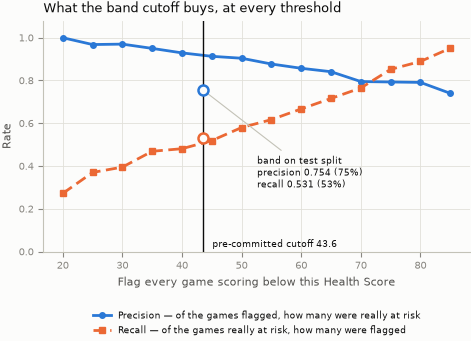

  saved fig10_threshold_curve.png


In [11]:
# F10 : precision and recall at every cutoff
# i want this to read as a decision rather than a number - flag more games and catch
# more of them, at the cost of more false alarms
curve=tables['threshold_precision_recall'].sort_values('health_below')
committed=settings['bands']['at_risk_below']
band=tables['band_performance'].iloc[0]

fig,ax=plt.subplots(figsize=(text_width,3.0))
ax.plot(curve['health_below'],curve['precision'],color=COLOUR['health'],marker='o',
        markersize=4,label='Precision — of the games flagged, how many were really at risk',zorder=3)
ax.plot(curve['health_below'],curve['recall'],color=COLOUR['baseline'],marker='s',
        markersize=4,ls=(0,(4,2)),label='Recall — of the games really at risk, how many were flagged',zorder=3)

# here i show the committed cutoff and what the band actually delivers on the test
# split. the curve runs over the scored set so its value at 43.6 is not the same
# number as the band precision, and i show both rather than mixing them up
ax.axvline(committed,color=PRIMARY,lw=1.0,zorder=4)
ax.annotate(f'pre-committed cutoff {committed}',xy=(committed,0.035),
            xytext=(committed+1.5,0.035),fontsize=6.5,color=PRIMARY,va='center')
ax.scatter([committed],[band['test_precision']],s=52,facecolor=SURFACE,
           edgecolor=COLOUR['health'],linewidth=1.8,zorder=6)
ax.scatter([committed],[band['test_recall']],s=52,facecolor=SURFACE,
           edgecolor=COLOUR['baseline'],linewidth=1.8,zorder=6)
ax.annotate(f"band on test split\nprecision {band['test_precision']:.3f} ({band['test_precision']*100:.0f}%)\n"
            f"recall {band['test_recall']:.3f} ({band['test_recall']*100:.0f}%)",
            xy=(committed,band['test_precision']),xytext=(committed+9,0.30),
            fontsize=6.3,color=PRIMARY,
            arrowprops=dict(arrowstyle='-',color=AXIS,lw=0.8))

ax.set_ylim(0,1.08); ax.set_xlabel('Flag every game scoring below this Health Score')
ax.set_ylabel('Rate'); ax.grid(True,zorder=0); ax.set_axisbelow(True)
ax.legend(loc='upper center',bbox_to_anchor=(0.5,-0.22),ncol=1,fontsize=6.5)
ax.set_title('What the band cutoff buys, at every threshold',color=PRIMARY,loc='left')
save(fig,'fig10_threshold_curve')
plt.show()

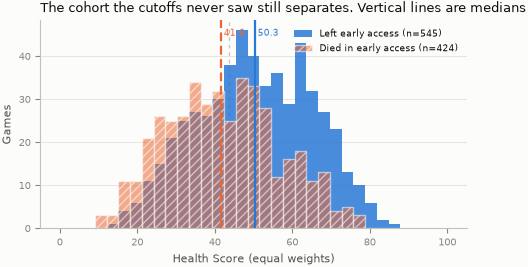

  saved fig11_cohort_separation.png


In [12]:
# F11 : where the two cohorts separate
# i draw this as a distribution rather than two medians. the died-in-EA cohort never
# trained anything, so the separation is the instrument working on games it has
# not seen
launched=scores[scores['cohort']=='launched']['health_score_equal'].dropna()
died=scores[scores['cohort']=='died_in_early_access']['health_score_equal'].dropna()

fig,ax=plt.subplots(figsize=(text_width,2.7))
bins=np.linspace(0,100,34)
ax.hist(launched,bins=bins,color=COLOUR['health'],alpha=0.85,label=f'Left early access (n={len(launched)})',zorder=3)
ax.hist(died,bins=bins,color=COLOUR['baseline'],alpha=0.55,hatch='////',edgecolor=SURFACE,
        label=f'Died in early access (n={len(died)})',zorder=3)
for series,colour,ls in ((launched,COLOUR['health'],'-'),(died,COLOUR['baseline'],(0,(4,2)))):
    ax.axvline(series.median(),color=colour,lw=1.6,ls=ls,zorder=5)
    ax.text(series.median(),ax.get_ylim()[1]*0.96,f' {series.median():.1f}',
            fontsize=6.5,color=colour,va='top')
ax.axvline(settings['bands']['at_risk_below'],color=AXIS,lw=0.9,ls=(0,(3,3)),zorder=1)
ax.set_xlabel('Health Score (equal weights)'); ax.set_ylabel('Games')
ax.grid(True,axis='y',zorder=0); ax.set_axisbelow(True)
ax.legend(loc='upper right',fontsize=6.5)
ax.set_title('The cohort the cutoffs never saw still separates. Vertical lines are medians',
             color=PRIMARY,loc='left')
save(fig,'fig11_cohort_separation')
plt.show()